# Câu 1

Final Momentum: [-1.00713767  0.5002788 ]
Final Nesterov: [-8.31221680e-01  1.62911789e-06]


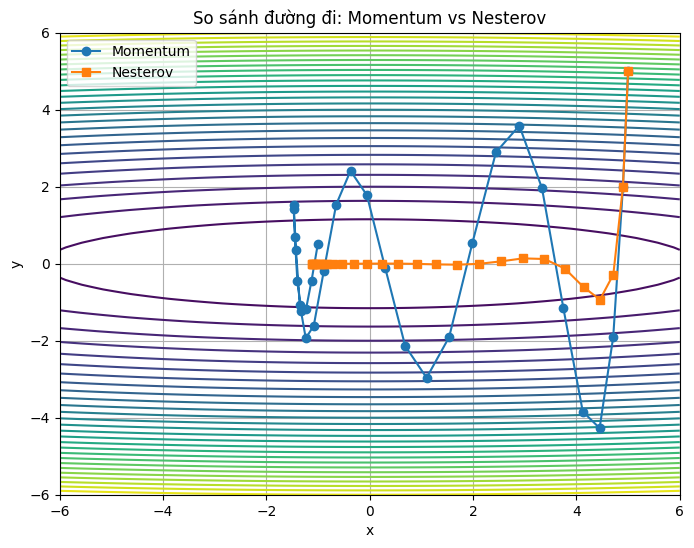

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# ===== HÀM MỤC TIÊU =====
# =========================

def f(w):
    x, y = w
    return 0.1 * x**2 + 3 * y**2

def grad_f(w):
    x, y = w
    return np.array([0.2 * x, 6 * y])


# =========================
# ===== MOMENTUM =========
# =========================

def momentum_opt(w_init, lr=0.1, beta=0.9, epochs=30):
    w = np.array(w_init, dtype=float)
    v = np.zeros_like(w)

    history = []

    for epoch in range(epochs):
        history.append(w.copy())

        grad = grad_f(w)

        v = beta * v - lr * grad
        w = w + v

    return np.array(history)


# =========================
# ===== NESTEROV =========
# =========================

def nesterov_opt(w_init, lr=0.1, beta=0.9, epochs=30):
    w = np.array(w_init, dtype=float)
    v = np.zeros_like(w)

    history = []

    for epoch in range(epochs):
        history.append(w.copy())

        # lookahead
        w_look = w + beta * v

        grad = grad_f(w_look)

        v = beta * v - lr * grad
        w = w + v

    return np.array(history)


# =========================
# ===== CHẠY ============
# =========================

w_init = np.array([5.0, 5.0])

mom_path = momentum_opt(w_init)
nag_path = nesterov_opt(w_init)

print("Final Momentum:", mom_path[-1])
print("Final Nesterov:", nag_path[-1])


# =========================
# ===== VẼ CONTOUR ======
# =========================

x = np.linspace(-6, 6, 100)
y = np.linspace(-6, 6, 100)
X, Y = np.meshgrid(x, y)
Z = 0.1 * X**2 + 3 * Y**2

plt.figure(figsize=(8,6))

# contour
plt.contour(X, Y, Z, levels=30)

# đường đi
plt.plot(mom_path[:,0], mom_path[:,1], 'o-', label="Momentum")
plt.plot(nag_path[:,0], nag_path[:,1], 's-', label="Nesterov")

plt.xlabel("x")
plt.ylabel("y")
plt.title("So sánh đường đi: Momentum vs Nesterov")

plt.legend()
plt.grid()

plt.show()

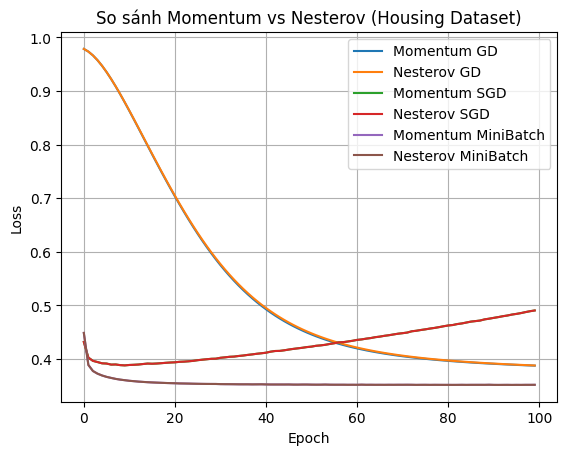

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================
# ===== LOAD DATA =========
# =========================

def load_data(path):
    df = pd.read_csv(path)

    # fix NaN
    df = df.fillna(df.median(numeric_only=True))

    # one-hot
    df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

    X = df.drop('median_house_value', axis=1).values
    y = df['median_house_value'].values

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # scale X
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # scale y
    y_mean, y_std = y_train.mean(), y_train.std()
    y_train = (y_train - y_mean) / y_std
    y_test = (y_test - y_mean) / y_std

    return X_train, X_test, y_train, y_test


# =========================
# ===== MODEL ============
# =========================

class LinearRegression:
    def __init__(self, lr=0.001, epochs=100, beta=0.9):
        self.lr = lr
        self.epochs = epochs
        self.beta = beta

    def init_params(self, d):
        np.random.seed(42)
        self.w = np.random.randn(d) * 0.01
        self.b = 0

    def loss(self, X, y):
        pred = X @ self.w + self.b
        return np.mean((pred - y) ** 2)

    def grad(self, X, y, w, b):
        n = len(y)
        pred = X @ w + b
        dw = (2/n) * X.T @ (pred - y)
        db = (2/n) * np.sum(pred - y)
        return dw, db

    # ===== MOMENTUM =====
    def fit_momentum(self, X, y, mode="gd", batch_size=32):
        n, d = X.shape
        self.init_params(d)

        v_w = np.zeros(d)
        v_b = 0

        history = []

        for epoch in range(self.epochs):

            idx = np.random.permutation(n)
            X_s, y_s = X[idx], y[idx]

            if mode == "gd":
                batches = [(X_s, y_s)]
            elif mode == "sgd":
                batches = [(X_s[i:i+1], y_s[i:i+1]) for i in range(n)]
            else:
                batches = [(X_s[i:i+batch_size], y_s[i:i+batch_size])
                           for i in range(0, n, batch_size)]

            for Xb, yb in batches:
                dw, db = self.grad(Xb, yb, self.w, self.b)

                # gradient clipping
                dw = np.clip(dw, -1, 1)
                db = np.clip(db, -1, 1)

                v_w = self.beta * v_w - self.lr * dw
                v_b = self.beta * v_b - self.lr * db

                self.w += v_w
                self.b += v_b

            history.append(self.loss(X, y))

        return history

    # ===== NESTEROV =====
    def fit_nesterov(self, X, y, mode="gd", batch_size=32):
        n, d = X.shape
        self.init_params(d)

        v_w = np.zeros(d)
        v_b = 0

        history = []

        for epoch in range(self.epochs):

            idx = np.random.permutation(n)
            X_s, y_s = X[idx], y[idx]

            if mode == "gd":
                batches = [(X_s, y_s)]
            elif mode == "sgd":
                batches = [(X_s[i:i+1], y_s[i:i+1]) for i in range(n)]
            else:
                batches = [(X_s[i:i+batch_size], y_s[i:i+batch_size])
                           for i in range(0, n, batch_size)]

            for Xb, yb in batches:
                # lookahead
                w_look = self.w + self.beta * v_w
                b_look = self.b + self.beta * v_b

                dw, db = self.grad(Xb, yb, w_look, b_look)

                # clipping
                dw = np.clip(dw, -1, 1)
                db = np.clip(db, -1, 1)

                v_w = self.beta * v_w - self.lr * dw
                v_b = self.beta * v_b - self.lr * db

                self.w += v_w
                self.b += v_b

            history.append(self.loss(X, y))

        return history


# =========================
# ===== MAIN =============
# =========================

if __name__ == "__main__":

    X_train, X_test, y_train, y_test = load_data("../datasets/housing.csv")

    epochs = 100

    # ===== GD =====
    mom_gd = LinearRegression(lr=0.001, epochs=epochs)
    hist_mom_gd = mom_gd.fit_momentum(X_train, y_train, mode="gd")

    nag_gd = LinearRegression(lr=0.001, epochs=epochs)
    hist_nag_gd = nag_gd.fit_nesterov(X_train, y_train, mode="gd")

    # ===== SGD =====
    mom_sgd = LinearRegression(lr=1e-5, epochs=epochs)
    hist_mom_sgd = mom_sgd.fit_momentum(X_train, y_train, mode="sgd")

    nag_sgd = LinearRegression(lr=1e-5, epochs=epochs)
    hist_nag_sgd = nag_sgd.fit_nesterov(X_train, y_train, mode="sgd")

    # ===== Mini-batch =====
    mom_mb = LinearRegression(lr=1e-4, epochs=epochs)
    hist_mom_mb = mom_mb.fit_momentum(X_train, y_train, mode="minibatch")

    nag_mb = LinearRegression(lr=1e-4, epochs=epochs)
    hist_nag_mb = nag_mb.fit_nesterov(X_train, y_train, mode="minibatch")

    # =========================
    # ===== PLOT ============
    # =========================

    plt.figure()

    plt.plot(hist_mom_gd, label="Momentum GD")
    plt.plot(hist_nag_gd, label="Nesterov GD")

    plt.plot(hist_mom_sgd, label="Momentum SGD")
    plt.plot(hist_nag_sgd, label="Nesterov SGD")

    plt.plot(hist_mom_mb, label="Momentum MiniBatch")
    plt.plot(hist_nag_mb, label="Nesterov MiniBatch")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("So sánh Momentum vs Nesterov (Housing Dataset)")
    plt.legend()
    plt.grid()

    plt.show()